# FlavorMetrics: NumPy & Visualization for the Food Industry

A complete, from-**beginning-to-advanced** project applying every technique
from **Chapter 2 ("Introduction to NumPy")** and **Chapter 4 ("Visualization
with Matplotlib")** of the *Python Data Science Handbook* to a realistic
food-industry analytics problem.

### The scenario

You're a data analyst at **FlavorMetrics Foods**, a packaged-food producer
and multi-region retail/restaurant chain. Your job spans:

- **Product & nutrition science** — comparing calories, macros, sugar, and
  sodium across the product catalog
- **Cold-chain food safety** — monitoring refrigerated-shipment temperature
  sensors for excursions that could spoil product or trigger a recall
- **Recipe / production scaling** — scaling ingredient formulations from a
  test-kitchen batch up to full production runs
- **Sales & merchandising analytics** — price, rating, and sales patterns
  across categories and store locations
- **Quality control & inspection** — structured batch-inspection records

Every technique below is demonstrated **on this data**, not on toy arrays,
and every code cell is commented to explain not just *what* it does but
*why* a food-industry analyst would do it.

### Roadmap

**Part A — NumPy, beginning to advanced** *(ref: Chapter 2)*
1. 02.01 — Understanding data types
2. 02.02 — The basics of NumPy arrays
3. 02.03 — Computation on arrays: ufuncs
4. 02.04 — Aggregations
5. 02.05 — Broadcasting
6. 02.06 — Boolean arrays and masks
7. 02.07 — Fancy indexing
8. 02.08 — Sorting
9. 02.09 — Structured arrays

**Part B — Visualization, beginning to advanced** *(ref: Chapter 4)*
10. 04.01 — Simple line plots
11. 04.02 — Simple scatter plots
12. 04.03 — Error bars
13. 04.04 — Density and contour plots
14. 04.05 — Histograms and binning
15. 04.06 — Customizing legends
16. 04.07 — Customizing colorbars
17. 04.08 — Multiple subplots
18. 04.09 — Text and annotation
19. 04.10 — Customizing ticks
20. 04.11 — Settings and stylesheets
21. 04.12 — Three-dimensional plotting
22. 04.13 — Geographic data (modern lightweight alternative to Basemap)
23. 04.14 — Visualization with Seaborn
24. 04.15 — Wrap-up & further resources


In [1]:
# Core imports used throughout the notebook.
# NOTE ON STYLE: this notebook leans on the NumPy array API directly (not
# pandas) for Part A, exactly as the handbook's NumPy chapter does -- because
# the whole point of that chapter is learning to think in arrays. We bring
# pandas back in lightly wherever a labeled table is genuinely more readable
# (e.g. printing a summary), but every core computation is done with NumPy.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# A fixed seed makes every random food-industry dataset below reproducible
rng = np.random.default_rng(2024)

print("numpy     :", np.__version__)
print("matplotlib:", mpl.__version__)
print("seaborn   :", sns.__version__)


numpy     : 2.4.4
matplotlib: 3.10.8
seaborn   : 0.13.2


## 0. Building the FlavorMetrics datasets

We synthesize five linked datasets that will run through the rest of the
notebook: a **product/nutrition matrix**, a **cold-chain sensor log**, a
**recipe-scaling matrix**, a **store-location** table, and a **structured
quality-inspection** record array. All are self-contained (no files needed)
so the notebook runs anywhere.


In [2]:
# ---------------------------------------------------------------
# 1) PRODUCT & NUTRITION DATA
#    A (products x nutrients) NumPy matrix -- the core array we'll use
#    for ufuncs, aggregation, broadcasting, masking, fancy indexing, sorting.
# ---------------------------------------------------------------
categories = ["Snacks", "Beverages", "Dairy", "Bakery", "Frozen Meals", "Produce"]
n_per_category = 10
n_products = n_per_category * len(categories)

product_category = np.repeat(categories, n_per_category)   # shape (n_products,)

product_names = np.array([
    f"{cat[:4].upper()}-{i+1:02d}" for cat in categories for i in range(n_per_category)
])

# Nutrient columns, in a fixed order we'll reuse throughout the notebook
nutrient_names = np.array(["calories", "protein_g", "fat_g", "carbs_g", "sugar_g", "sodium_mg", "fiber_g"])

# Category-level nutrition profiles (mean, std) so the synthetic data has
# realistic structure -- e.g. Beverages high sugar, low protein; Dairy
# higher protein/fat; Produce low calorie/sodium, higher fiber.
profiles = {
    #                 calories   protein   fat     carbs    sugar    sodium    fiber
    "Snacks":       ((150, 40), (2.5, 1),  (8, 3),  (18, 5), (5, 3),  (220, 60), (1.5, 0.8)),
    "Beverages":    ((120, 60), (0.5, 0.4),(0.2, 0.3),(29, 12),(27, 11),(35, 20), (0.1, 0.2)),
    "Dairy":        ((160, 45), (8, 2.5),  (9, 3),  (11, 4),  (10, 4), (120, 40), (0.2, 0.3)),
    "Bakery":       ((280, 70), (5, 1.8),  (12, 4), (38, 8),  (16, 6), (300, 80), (2.0, 1.0)),
    "Frozen Meals": ((340, 80), (16, 5),   (14, 5), (34, 9),  (6, 3),  (650, 150),(3.5, 1.5)),
    "Produce":      ((60, 25),  (2, 1.2),  (0.5, 0.5),(13, 6),(6, 3),  (10, 8),   (3.5, 1.8)),
}

nutrients = np.zeros((n_products, len(nutrient_names)))
for i, cat in enumerate(categories):
    rows = slice(i * n_per_category, (i + 1) * n_per_category)
    for j, (mean, std) in enumerate(profiles[cat]):
        nutrients[rows, j] = rng.normal(mean, std, n_per_category)

# Clip to physically sensible ranges (no negative grams/mg/calories)
nutrients = np.clip(nutrients, 0, None)

print("nutrients shape:", nutrients.shape, " dtype:", nutrients.dtype)
nutrients[:3].round(1)


nutrients shape: (60, 7)  dtype: float64


array([[191.2,   3.1,  10.7,  18.3,   3.8, 265.7,   1. ],
       [215.7,   1.8,   3.6,  20.1,   0.8, 204.3,   0.9],
       [195.9,   1.4,   6.4,  19.1,   0. , 221. ,   1. ]])

In [3]:
# Prices ($) and star ratings (1-5), correlated loosely with calories/category
# for realism (frozen meals & bakery priced higher; produce cheaper)
category_price_base = {"Snacks": 3.5, "Beverages": 2.0, "Dairy": 4.0,
                        "Bakery": 5.0, "Frozen Meals": 6.5, "Produce": 2.5}
prices = np.array([
    max(0.5, rng.normal(category_price_base[cat], 1.1)) for cat in product_category
])
ratings = np.clip(rng.normal(4.0, 0.5, n_products), 1, 5)

# Allergen flags: (n_products x n_allergens) boolean matrix
allergen_names = np.array(["milk", "eggs", "peanuts", "tree_nuts", "soy", "wheat", "gluten"])
allergen_prob_by_cat = {
    "Snacks":       [0.05, 0.05, 0.20, 0.15, 0.25, 0.40, 0.35],
    "Beverages":    [0.10, 0.00, 0.00, 0.00, 0.05, 0.00, 0.00],
    "Dairy":        [0.95, 0.10, 0.00, 0.00, 0.05, 0.05, 0.05],
    "Bakery":       [0.35, 0.55, 0.10, 0.15, 0.20, 0.85, 0.80],
    "Frozen Meals": [0.30, 0.15, 0.05, 0.05, 0.30, 0.45, 0.35],
    "Produce":      [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
}
allergens = np.zeros((n_products, len(allergen_names)), dtype=bool)
for i, cat in enumerate(categories):
    rows = slice(i * n_per_category, (i + 1) * n_per_category)
    probs = allergen_prob_by_cat[cat]
    for j, p in enumerate(probs):
        allergens[rows, j] = rng.random(n_per_category) < p

print("prices shape:", prices.shape, " allergens shape:", allergens.shape)


prices shape: (60,)  allergens shape: (60, 7)


In [4]:
# ---------------------------------------------------------------
# 2) COLD-CHAIN SENSOR LOG
#    A (shipments x hours) matrix of refrigerated-truck temperature
#    readings in Celsius -- the target for ufuncs/aggregates/broadcasting/
#    masking/fancy-indexing/sorting in the food-SAFETY context.
# ---------------------------------------------------------------
n_shipments = 24
n_hours = 72   # 3-day transit window
target_temp_c = 4.0   # refrigerated-food safe storage target

# Each shipment has its own truck-unit baseline offset and noise level;
# a handful of shipments simulate a REAL cooling-unit malfunction (temp drifts up)
baseline_offset = rng.normal(0, 0.6, n_shipments)
noise_level = rng.uniform(0.3, 0.9, n_shipments)

cold_chain = np.zeros((n_shipments, n_hours))
malfunctioning = rng.choice(n_shipments, size=4, replace=False)  # 4 problem shipments

for s in range(n_shipments):
    trend = np.zeros(n_hours)
    if s in malfunctioning:
        # Cooling failure: temperature drifts upward starting partway through transit
        onset = rng.integers(15, 40)
        trend[onset:] = np.linspace(0, rng.uniform(6, 11), n_hours - onset)
    cold_chain[s] = target_temp_c + baseline_offset[s] + trend + rng.normal(0, noise_level[s], n_hours)

print("cold_chain shape:", cold_chain.shape)
print("malfunctioning shipment indices:", sorted(malfunctioning))
cold_chain[:2, :6].round(2)


cold_chain shape: (24, 72)
malfunctioning shipment indices: [np.int64(0), np.int64(5), np.int64(13), np.int64(20)]


array([[3.25, 1.67, 1.89, 1.24, 2.29, 1.72],
       [2.99, 4.79, 3.2 , 3.  , 3.18, 1.4 ]])

In [5]:
# ---------------------------------------------------------------
# 3) RECIPE / PRODUCTION SCALING MATRIX
#    A (ingredients x recipes) matrix of gram quantities PER BASE BATCH --
#    the target for the broadcasting section (scaling many recipes by many
#    different production multipliers at once).
# ---------------------------------------------------------------
ingredient_names = np.array(["flour", "sugar", "butter", "eggs_g", "milk_g", "salt", "leavening", "cocoa"])
recipe_names = np.array(["Classic Cookie", "Brownie", "Muffin", "Pancake Mix"])

# Base-batch formulation (grams), one column per recipe
recipe_matrix = np.array([
    # Cookie  Brownie  Muffin  Pancake
    [ 500,     220,     400,    450],   # flour
    [ 300,     380,     220,     60],   # sugar
    [ 250,     200,     150,     80],   # butter
    [  90,     110,      90,     60],   # eggs (g)
    [   0,       0,     180,    500],   # milk (g)
    [   4,       3,       4,      5],   # salt
    [   6,       0,      10,      8],   # leavening (baking powder/soda)
    [   0,     140,       0,      0],   # cocoa
], dtype=float)

print("recipe_matrix shape:", recipe_matrix.shape)
recipe_matrix


recipe_matrix shape: (8, 4)


array([[500., 220., 400., 450.],
       [300., 380., 220.,  60.],
       [250., 200., 150.,  80.],
       [ 90., 110.,  90.,  60.],
       [  0.,   0., 180., 500.],
       [  4.,   3.,   4.,   5.],
       [  6.,   0.,  10.,   8.],
       [  0., 140.,   0.,   0.]])

In [6]:
# ---------------------------------------------------------------
# 4) STORE LOCATIONS (for the geographic-data section)
#    Approximate lat/lon for company locations across the continental US,
#    plus a monthly sales volume per store.
# ---------------------------------------------------------------
n_stores = 45
# Continental US bounding box (approx.)
lat_range, lon_range = (25.0, 49.0), (-124.0, -67.0)

store_lat = rng.uniform(*lat_range, n_stores)
store_lon = rng.uniform(*lon_range, n_stores)
# Bias sales higher for stores nearer the (rough) population-dense east/west coasts
coastal_bonus = np.exp(-((store_lon + 95) ** 2) / 600) * 40_000
store_sales = np.clip(rng.normal(60_000, 18_000, n_stores) + coastal_bonus, 5_000, None)
store_region = np.where(store_lon < -100, "West", "East")

print("store_lat/lon shape:", store_lat.shape)


store_lat/lon shape: (45,)


In [7]:
# ---------------------------------------------------------------
# 5) STRUCTURED QUALITY-INSPECTION RECORDS (for 02.09, structured arrays)
#    Each record mixes types the way a real QC log does: text, integer
#    batch IDs, floats, booleans, and dates -- a natural fit for NumPy's
#    structured (compound dtype) arrays.
# ---------------------------------------------------------------
n_inspections = 20
inspection_dtype = np.dtype([
    ("batch_id", "i4"),
    ("product", "U10"),
    ("category", "U15"),
    ("weight_kg", "f8"),
    ("moisture_pct", "f4"),
    ("passed", "?"),
    ("inspection_date", "datetime64[D]"),
])

inspections = np.zeros(n_inspections, dtype=inspection_dtype)
inspections["batch_id"] = np.arange(1001, 1001 + n_inspections)
sample_idx = rng.choice(n_products, n_inspections, replace=False)
inspections["product"] = product_names[sample_idx]
inspections["category"] = product_category[sample_idx]
inspections["weight_kg"] = rng.normal(12.5, 1.2, n_inspections).round(2)
inspections["moisture_pct"] = rng.normal(8.5, 1.5, n_inspections).round(1)
inspections["passed"] = rng.random(n_inspections) > 0.15
inspections["inspection_date"] = (np.datetime64("2024-01-01") +
                                    rng.integers(0, 300, n_inspections).astype("timedelta64[D]"))

print("structured array dtype:\n", inspections.dtype)
inspections[:5]


structured array dtype:
 [('batch_id', '<i4'), ('product', '<U10'), ('category', '<U15'), ('weight_kg', '<f8'), ('moisture_pct', '<f4'), ('passed', '?'), ('inspection_date', '<M8[D]')]


array([(1001, 'BAKE-03', 'Bakery', 12.63, 8.6, False, '2024-09-16'),
       (1002, 'FROZ-09', 'Frozen Meals', 14.64, 7.7,  True, '2024-03-05'),
       (1003, 'BAKE-06', 'Bakery', 13.35, 8.4,  True, '2024-05-04'),
       (1004, 'PROD-04', 'Produce', 13.58, 8.9, False, '2024-08-11'),
       (1005, 'BEVE-03', 'Beverages', 12.18, 7. ,  True, '2024-06-11')],
      dtype=[('batch_id', '<i4'), ('product', '<U10'), ('category', '<U15'), ('weight_kg', '<f8'), ('moisture_pct', '<f4'), ('passed', '?'), ('inspection_date', '<M8[D]')])

# Part A — NumPy from Beginning to Advanced

## 1. Understanding Data Types  *(ref: 02.01)*

Every NumPy array is a contiguous block of **one fixed data type** — this is
what makes NumPy fast, but it also means choosing the right `dtype` matters:
too narrow and you silently lose precision/range; too wide and you waste
memory on a large dataset.


In [8]:
# Python lists CAN mix types -- but pay a real per-element overhead, because
# each element is a full Python object with its own type info.
mixed_list = [150, "Snacks", 3.5, True]
print([type(x).__name__ for x in mixed_list])

# A NumPy array insists on ONE dtype -- here it upcasts everything to a
# generic string representation, illustrating the "least common denominator"
# behavior when you force mixed data into a homogeneous array
forced = np.array(mixed_list)
print(forced, forced.dtype)


['int', 'str', 'float', 'bool']
['150' 'Snacks' '3.5' 'True'] <U32


In [9]:
# Choosing dtypes deliberately for our real data:
# - calories/prices need decimals -> float
# - a "category code" (0-5) fits comfortably in a tiny signed int
# - an allergen flag is naturally boolean (1 byte), not a float

category_codes = np.array([categories.index(c) for c in product_category], dtype=np.int8)
print("category_codes dtype:", category_codes.dtype, " nbytes:", category_codes.nbytes)

# Compare memory cost of the SAME information stored as float64 vs int8
as_float64 = category_codes.astype(np.float64)
print(f"int8 storage : {category_codes.nbytes} bytes")
print(f"float64 storage: {as_float64.nbytes} bytes  ({as_float64.nbytes / category_codes.nbytes:.0f}x more)")


category_codes dtype: int8  nbytes: 60
int8 storage : 60 bytes
float64 storage: 480 bytes  (8x more)


In [10]:
# float32 vs float64 for the nutrition matrix: float32 halves memory, at the
# cost of precision -- usually a fine trade for nutrition data (no one cares
# about calories to 7 significant figures), but worth checking explicitly
nutrients_f32 = nutrients.astype(np.float32)
print("float64 nutrients:", nutrients.nbytes, "bytes")
print("float32 nutrients:", nutrients_f32.nbytes, "bytes")
print("max absolute difference after downcast:", np.abs(nutrients - nutrients_f32).max())


float64 nutrients: 3360 bytes
float32 nutrients: 1680 bytes
max absolute difference after downcast: 2.582393983630027e-05


In [11]:
# Every array exposes its dtype AND itemsize directly
for name, arr in [("nutrients", nutrients), ("category_codes", category_codes),
                   ("allergens", allergens), ("prices", prices)]:
    print(f"{name:16s} dtype={str(arr.dtype):8s} itemsize={arr.itemsize} bytes  shape={arr.shape}")


nutrients        dtype=float64  itemsize=8 bytes  shape=(60, 7)
category_codes   dtype=int8     itemsize=1 bytes  shape=(60,)
allergens        dtype=bool     itemsize=1 bytes  shape=(60, 7)
prices           dtype=float64  itemsize=8 bytes  shape=(60,)


## 2. The Basics of NumPy Arrays  *(ref: 02.02)*

Attributes, indexing, slicing, reshaping, and concatenation — the everyday
mechanics of working with an array, all demonstrated on the nutrition matrix.


In [12]:
# Core array attributes
print("ndim :", nutrients.ndim)
print("shape:", nutrients.shape, " -> (products, nutrients)")
print("size :", nutrients.size, " total scalar values")
print("dtype:", nutrients.dtype)


ndim : 2
shape: (60, 7)  -> (products, nutrients)
size : 420  total scalar values
dtype: float64


In [13]:
# Single-element indexing: calories (column 0) of the 5th product (row 4)
print("Product:", product_names[4], " | calories:", nutrients[4, 0])

# Row indexing: the FULL nutrition profile of one product
print(dict(zip(nutrient_names, nutrients[4].round(1))))


Product: SNAC-05  | calories: 94.28799614492527
{np.str_('calories'): np.float64(94.3), np.str_('protein_g'): np.float64(2.5), np.str_('fat_g'): np.float64(6.0), np.str_('carbs_g'): np.float64(14.7), np.str_('sugar_g'): np.float64(1.5), np.str_('sodium_mg'): np.float64(295.9), np.str_('fiber_g'): np.float64(1.1)}


In [14]:
# Slicing: the first 3 products' calories/protein/fat columns only
nutrients[:3, :3].round(1)


array([[191.2,   3.1,  10.7],
       [215.7,   1.8,   3.6],
       [195.9,   1.4,   6.4]])

In [15]:
# NumPy slices are VIEWS, not copies -- editing a slice edits the original!
# This matters a lot in a real pipeline: always .copy() before mutating a
# slice you don't want to affect the source array.
demo = nutrients[:2, :2].copy()   # take a COPY here on purpose
demo[0, 0] = -999
print("Modified copy:\n", demo)
print("Original untouched:\n", nutrients[:2, :2])


Modified copy:
 [[-999.            3.13975955]
 [ 215.67680163    1.76867748]]
Original untouched:
 [[191.15427496   3.13975955]
 [215.67680163   1.76867748]]


In [16]:
# Reshaping: flatten the (products x nutrients) matrix, then restore it --
# useful when feeding data into an API/model that expects a flat vector
flat = nutrients.reshape(-1)   # -1 lets NumPy infer the size
print("flat shape:", flat.shape)

restored = flat.reshape(n_products, len(nutrient_names))
print("round-trip matches original:", np.array_equal(restored, nutrients))


flat shape: (420,)
round-trip matches original: True


In [17]:
# Concatenation: appending a newly-tested batch of 3 products' nutrient rows
new_products_nutrients = np.array([
    [210, 4.0, 9.0, 26.0, 8.0, 240.0, 2.0],
    [90,  1.0, 0.2, 22.0, 18.0, 15.0, 1.0],
    [305, 14.0, 11.0, 30.0, 5.0, 580.0, 3.0],
])
expanded_nutrients = np.concatenate([nutrients, new_products_nutrients], axis=0)
print("before:", nutrients.shape, " after concatenation:", expanded_nutrients.shape)


before: (60, 7)  after concatenation: (63, 7)


## 3. Computation on Arrays: ufuncs  *(ref: 02.03)*

NumPy's universal functions (ufuncs) apply element-wise operations at
C speed, with no explicit Python loop — essential once a dataset grows
past a handful of rows.


In [18]:
# WHY ufuncs matter: compare a Python-loop unit conversion to a vectorized one
def celsius_to_fahrenheit_loop(arr):
    out = np.empty_like(arr)
    it = np.nditer(arr, flags=["multi_index"])
    for x in it:
        out[it.multi_index] = x * 9 / 5 + 32
    return out

import time
t0 = time.perf_counter()
_ = celsius_to_fahrenheit_loop(cold_chain)
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
cold_chain_f = cold_chain * 9 / 5 + 32     # <-- this IS a ufunc expression
t_ufunc = time.perf_counter() - t0

print(f"explicit loop : {t_loop*1000:7.3f} ms")
print(f"ufunc (vector): {t_ufunc*1000:7.3f} ms")
print(f"speedup: {t_loop / t_ufunc:.0f}x on a {cold_chain.size:,}-element array")


explicit loop :   2.730 ms
ufunc (vector):   1.135 ms
speedup: 2x on a 1,728-element array


In [19]:
# Arithmetic ufuncs: convert nutrition-matrix sodium from mg to grams,
# and compute a %-of-daily-value column for sodium (FDA DV = 2300 mg)
sodium_mg = nutrients[:, nutrient_names.tolist().index("sodium_mg")]
sodium_g = sodium_mg / 1000                 # np.divide under the hood
sodium_pct_dv = sodium_mg / 2300 * 100       # np.multiply/np.divide

print("Sample sodium (mg / g / %DV):")
np.stack([sodium_mg[:5], sodium_g[:5], sodium_pct_dv[:5]], axis=1).round(2)


Sample sodium (mg / g / %DV):


array([[2.6570e+02, 2.7000e-01, 1.1550e+01],
       [2.0429e+02, 2.0000e-01, 8.8800e+00],
       [2.2105e+02, 2.2000e-01, 9.6100e+00],
       [3.0012e+02, 3.0000e-01, 1.3050e+01],
       [2.9593e+02, 3.0000e-01, 1.2870e+01]])

In [20]:
# A ufunc for calories FROM MACROS -- the Atwater system: 4 kcal/g protein,
# 9 kcal/g fat, 4 kcal/g carbs. This is pure elementwise arithmetic across
# THREE columns at once, entirely vectorized.
protein = nutrients[:, 1]; fat = nutrients[:, 2]; carbs = nutrients[:, 3]
computed_calories = protein * 4 + fat * 9 + carbs * 4
labeled_calories = nutrients[:, 0]

# Where does the LABEL differ meaningfully from the physics-based estimate?
# (a real QA check food scientists actually run on nutrition-facts panels)
discrepancy = np.abs(labeled_calories - computed_calories)
print("Mean |label - computed| calories:", discrepancy.mean().round(1))
print("Largest discrepancy at product:", product_names[np.argmax(discrepancy)],
      " (label:", labeled_calories[np.argmax(discrepancy)].round(0),
      " computed:", computed_calories[np.argmax(discrepancy)].round(0), ")")


Mean |label - computed| calories: 56.2
Largest discrepancy at product: BEVE-03  (label: 238.0  computed: 4.0 )


In [21]:
# np.exp/np.log and comparison ufuncs together: a simple "sweetness index"
# on a log scale (sugar grams can span orders of magnitude across categories)
sugar = nutrients[:, nutrient_names.tolist().index("sugar_g")]
sweetness_index = np.log1p(sugar)   # log1p avoids log(0) issues cleanly
print(sweetness_index[:5].round(2))

# `out=` parameter: write results IN PLACE into a pre-allocated array --
# avoids an extra memory allocation, useful in a tight production loop
buffer = np.empty_like(sugar)
np.multiply(sugar, 1.0, out=buffer)
print("out= result matches:", np.array_equal(buffer, sugar))


[1.58 0.61 0.   2.07 0.92]
out= result matches: True


## 4. Aggregations  *(ref: 02.04)*

`sum`, `mean`, `std`, `min`/`max`, and friends collapse an array along one
or more axes — the `axis` argument is the single most important thing to
get right here.


In [22]:
# Whole-matrix aggregation: overall average nutrition profile across
# EVERY product in the catalog
print("Catalog-wide averages:")
for name, val in zip(nutrient_names, nutrients.mean(axis=0).round(1)):
    print(f"  {name:10s}: {val}")


Catalog-wide averages:
  calories  : 195.9
  protein_g : 5.7
  fat_g     : 7.5
  carbs_g   : 23.7
  sugar_g   : 11.5
  sodium_mg : 193.9
  fiber_g   : 2.0


In [23]:
# axis=0 aggregates DOWN each column (i.e. "per nutrient, across all products")
# axis=1 aggregates ACROSS each row (i.e. "per product, across all nutrients")
# -- a very common source of bugs; we verify both explicitly here.
per_nutrient_mean = nutrients.mean(axis=0)   # shape (7,)  one value per nutrient
per_product_total = nutrients.sum(axis=1)    # shape (n_products,) one value per product

print("per_nutrient_mean shape:", per_nutrient_mean.shape)
print("per_product_total shape:", per_product_total.shape)
print("\nHighest combined-nutrient-total product:", product_names[np.argmax(per_product_total)])


per_nutrient_mean shape: (7,)
per_product_total shape: (60,)

Highest combined-nutrient-total product: FROZ-04


In [24]:
# min/max/argmin/argmax -- the highest-sodium product in the ENTIRE catalog
sodium_col = nutrient_names.tolist().index("sodium_mg")
top_sodium_idx = np.argmax(nutrients[:, sodium_col])
print(f"Highest-sodium product: {product_names[top_sodium_idx]} "
      f"({product_category[top_sodium_idx]}) -- {nutrients[top_sodium_idx, sodium_col]:.0f} mg")

print(f"\nCatalog sodium range: {nutrients[:, sodium_col].min():.0f} to "
      f"{nutrients[:, sodium_col].max():.0f} mg")


Highest-sodium product: FROZ-04 (Frozen Meals) -- 787 mg

Catalog sodium range: 0 to 787 mg


In [25]:
# Cold-chain aggregation ACROSS TIME (axis=1): min/mean/max temperature
# reached by EACH shipment over its full 72-hour transit
shipment_min = cold_chain.min(axis=1)
shipment_mean = cold_chain.mean(axis=1)
shipment_max = cold_chain.max(axis=1)

print("Shipment  min    mean    max  (deg C)")
for i in range(5):
    print(f"  {i:2d}     {shipment_min[i]:5.2f}  {shipment_mean[i]:5.2f}  {shipment_max[i]:5.2f}")


Shipment  min    mean    max  (deg C)
   0      0.83   4.08  10.74
   1      1.40   3.57   5.54
   2      3.58   4.42   5.37
   3      2.74   3.45   4.31
   4      1.27   3.52   5.60


In [26]:
# np.std for VARIABILITY -- a shipment with high std is bouncing around a
# lot even if its mean looks fine, which matters for food safety
shipment_std = cold_chain.std(axis=1)
most_volatile = np.argmax(shipment_std)
print(f"Most volatile shipment: #{most_volatile}  (std={shipment_std[most_volatile]:.2f} C, "
      f"max={shipment_max[most_volatile]:.2f} C)")

# np.percentile: the 95th-percentile temperature reached, a common food-safety KPI
p95 = np.percentile(cold_chain, 95, axis=1)
print("\n95th-percentile temp per shipment (first 5):", p95[:5].round(2))


Most volatile shipment: #5  (std=3.27 C, max=14.84 C)

95th-percentile temp per shipment (first 5): [8.5  4.85 5.15 4.01 4.84]


## 5. Broadcasting  *(ref: 02.05)*

Broadcasting lets NumPy apply an operation between arrays of *compatible but
different* shapes without writing an explicit loop or manually tiling data.
This is where the recipe-scaling matrix earns its keep.


In [27]:
# recipe_matrix has shape (ingredients, recipes) = (8, 4). Suppose production
# needs to scale each recipe by a DIFFERENT multiplier this week (batch sizes
# vary by expected demand): a (4,) row vector broadcasts against the (8, 4)
# matrix's columns automatically -- NO explicit loop over ingredients needed.
batch_multipliers = np.array([12, 6, 20, 8])   # Cookie x12, Brownie x6, Muffin x20, Pancake x8
print("recipe_matrix shape:", recipe_matrix.shape, " multipliers shape:", batch_multipliers.shape)

scaled_recipes = recipe_matrix * batch_multipliers   # (8,4) * (4,) -> broadcasts over columns
scaled_recipes


recipe_matrix shape: (8, 4)  multipliers shape: (4,)


array([[6000., 1320., 8000., 3600.],
       [3600., 2280., 4400.,  480.],
       [3000., 1200., 3000.,  640.],
       [1080.,  660., 1800.,  480.],
       [   0.,    0., 3600., 4000.],
       [  48.,   18.,   80.,   40.],
       [  72.,    0.,  200.,   64.],
       [   0.,  840.,    0.,    0.]])

**Why this worked:** broadcasting compares shapes from the *right*.
`recipe_matrix` is `(8, 4)` and `batch_multipliers` is `(4,)` — treated as
`(1, 4)` — and since the trailing dimension (4) matches, NumPy stretches the
multiplier vector down all 8 ingredient rows without copying it 8 times in
memory.


In [28]:
# A DIFFERENT broadcast: scale by an INGREDIENT-specific shrink/waste factor
# (a (8,1) column vector) instead -- broadcasts across recipes this time.
waste_factor = np.array([1.03, 1.01, 1.05, 1.02, 1.00, 1.10, 1.08, 1.04]).reshape(-1, 1)
print("waste_factor shape:", waste_factor.shape)

adjusted_for_waste = recipe_matrix * waste_factor   # (8,4) * (8,1) -> broadcasts over rows
adjusted_for_waste.round(1)


waste_factor shape: (8, 1)


array([[515. , 226.6, 412. , 463.5],
       [303. , 383.8, 222.2,  60.6],
       [262.5, 210. , 157.5,  84. ],
       [ 91.8, 112.2,  91.8,  61.2],
       [  0. ,   0. , 180. , 500. ],
       [  4.4,   3.3,   4.4,   5.5],
       [  6.5,   0. ,  10.8,   8.6],
       [  0. , 145.6,   0. ,   0. ]])

In [29]:
# Combine BOTH broadcasts at once: batch-multiplier (row) AND waste-factor
# (column) applied together -- the full production-planning quantity matrix
full_production_plan = recipe_matrix * batch_multipliers * waste_factor
pd.DataFrame(full_production_plan.round(1), index=ingredient_names, columns=recipe_names)


,Classic Cookie,Brownie,Muffin,Pancake Mix
flour,6180.0,1359.6,8240.0,3708.0
sugar,3636.0,2302.8,4444.0,484.8
butter,3150.0,1260.0,3150.0,672.0
eggs_g,1101.6,673.2,1836.0,489.6
milk_g,0.0,0.0,3600.0,4000.0
salt,52.8,19.8,88.0,44.0
leavening,77.8,0.0,216.0,69.1
cocoa,0.0,873.6,0.0,0.0


In [30]:
# Broadcasting on the nutrition matrix: normalize every nutrient column to
# a 0-1 scale using (x - min) / (max - min) -- min/max are (7,) row vectors
# that broadcast against the (60, 7) matrix's rows.
col_min = nutrients.min(axis=0)
col_max = nutrients.max(axis=0)
normalized = (nutrients - col_min) / (col_max - col_min)   # (60,7)-(7,) broadcasts fine

print("normalized shape:", normalized.shape, " range check -> min:",
      normalized.min().round(3), " max:", normalized.max().round(3))
normalized[:3].round(2)


normalized shape: (60, 7)  range check -> min: 0.0  max: 1.0


array([[0.39, 0.16, 0.53, 0.32, 0.12, 0.34, 0.13],
       [0.45, 0.09, 0.17, 0.35, 0.03, 0.26, 0.12],
       [0.4 , 0.07, 0.31, 0.34, 0.  , 0.28, 0.13]])

## 6. Boolean Arrays and Masks  *(ref: 02.06)*

Comparison operators produce boolean arrays; used as masks, they let us
filter, count, and flag data without ever writing an `if` statement in a
loop — critical for the food-safety excursion checks below.


In [31]:
# A single comparison produces an element-wise boolean array
above_target = cold_chain > target_temp_c + 4   # more than 4C above the 4C target = concerning
print("above_target shape:", above_target.shape, " dtype:", above_target.dtype)
print("Total excursion READINGS across the whole fleet:", np.sum(above_target))


above_target shape: (24, 72)  dtype: bool
Total excursion READINGS across the whole fleet: 80


In [32]:
# Combine conditions with & / | (NOT `and`/`or`, which don't work element-wise)
# "dangerous" excursion: more than 8C AND sustained (we'll check duration next)
dangerous = (cold_chain > 8.0)
print("Readings above the 8C danger threshold:", dangerous.sum())

# np.any / np.all with axis=: which shipments had ANY dangerous reading at all?
shipment_had_danger = np.any(dangerous, axis=1)   # shape (n_shipments,)
print("Shipments with at least one dangerous reading:", np.where(shipment_had_danger)[0])


Readings above the 8C danger threshold: 80
Shipments with at least one dangerous reading: [ 0  5 13 20]


In [33]:
# Masking to SELECT: pull out the actual temperature values during excursions
# for the worst shipment, rather than just counting them
worst_shipment = np.argmax(cold_chain.max(axis=1))
excursion_readings = cold_chain[worst_shipment][dangerous[worst_shipment]]
print(f"Shipment #{worst_shipment}: {len(excursion_readings)} dangerous readings, "
      f"ranging {excursion_readings.min():.1f} to {excursion_readings.max():.1f} C")


Shipment #5: 40 dangerous readings, ranging 8.1 to 14.8 C


In [34]:
# Masking the PRODUCT catalog: high-sodium AND high-sugar products -- a
# useful "reformulation candidates" list for the food-science team
high_sodium = nutrients[:, nutrient_names.tolist().index("sodium_mg")] > 400
high_sugar = nutrients[:, nutrient_names.tolist().index("sugar_g")] > 15

reformulation_candidates = high_sodium & high_sugar
print(f"{reformulation_candidates.sum()} products flagged for reformulation review:")
product_names[reformulation_candidates]


1 products flagged for reformulation review:


array(['BAKE-06'], dtype='<U7')

In [35]:
# Masking allergen data: which SNACK products are peanut-free (safe for a
# peanut-free facility/school program)?
is_snack = product_category == "Snacks"
peanut_free = ~allergens[:, allergen_names.tolist().index("peanuts")]

snack_and_peanut_free = is_snack & peanut_free
print(f"{snack_and_peanut_free.sum()} of {is_snack.sum()} snack products are peanut-free")
product_names[snack_and_peanut_free]


10 of 10 snack products are peanut-free


array(['SNAC-01', 'SNAC-02', 'SNAC-03', 'SNAC-04', 'SNAC-05', 'SNAC-06',
       'SNAC-07', 'SNAC-08', 'SNAC-09', 'SNAC-10'], dtype='<U7')

## 7. Fancy Indexing  *(ref: 02.07)*

Indexing an array with an array of integers (rather than a single index or
slice) lets us select, reorder, or sample arbitrary, non-contiguous elements
in one vectorized step.


In [36]:
# Simple fancy indexing: pull nutrition rows for a HAND-PICKED shortlist of
# products (e.g. a monthly "nutrition spotlight" the marketing team requested)
spotlight_idx = np.array([3, 17, 22, 41, 55])
print("Spotlight products:", product_names[spotlight_idx])
nutrients[spotlight_idx].round(1)


Spotlight products: ['SNAC-04' 'BEVE-08' 'DAIR-03' 'FROZ-02' 'PROD-06']


array([[1.111e+02, 4.000e+00, 8.500e+00, 2.630e+01, 6.900e+00, 3.001e+02,
        1.000e+00],
       [1.057e+02, 3.000e-01, 9.000e-01, 0.000e+00, 2.480e+01, 3.730e+01,
        0.000e+00],
       [2.288e+02, 6.400e+00, 1.180e+01, 1.230e+01, 7.000e+00, 7.910e+01,
        1.000e-01],
       [2.959e+02, 1.340e+01, 1.940e+01, 2.840e+01, 8.000e+00, 6.886e+02,
        1.700e+00],
       [7.500e+01, 2.200e+00, 1.400e+00, 1.270e+01, 2.000e+00, 6.800e+00,
        4.800e+00]])

In [37]:
# Fancy indexing for RANDOM SAMPLING: pull a random QA sample of 8 products
# for a surprise audit (np.random.Generator.choice under the hood)
qa_sample_idx = rng.choice(n_products, size=8, replace=False)
print("QA audit sample:", product_names[qa_sample_idx])


QA audit sample: ['FROZ-05' 'SNAC-08' 'SNAC-07' 'BEVE-09' 'FROZ-03' 'PROD-03' 'PROD-04'
 'BEVE-10']


In [38]:
# Combined fancy + boolean indexing: from ONLY the reformulation-candidate
# products (boolean mask), fancy-index out just their name/category/sodium
candidate_rows = np.where(reformulation_candidates)[0]     # fancy index array from a mask
cols_of_interest = np.array([nutrient_names.tolist().index("sodium_mg"),
                               nutrient_names.tolist().index("sugar_g")])

print("Reformulation candidates -- sodium & sugar only:")
pd.DataFrame(nutrients[np.ix_(candidate_rows, cols_of_interest)],
             index=product_names[candidate_rows], columns=nutrient_names[cols_of_interest])


Reformulation candidates -- sodium & sugar only:

,sodium_mg,sugar_g
BAKE-06,405.458502,26.49698


In [39]:
# Fancy indexing to MODIFY values: apply a targeted 10% sodium reduction
# to exactly the reformulation candidates, leaving everything else untouched
nutrients_reformulated = nutrients.copy()
nutrients_reformulated[candidate_rows, nutrient_names.tolist().index("sodium_mg")] *= 0.90

before = nutrients[candidate_rows, nutrient_names.tolist().index("sodium_mg")]
after = nutrients_reformulated[candidate_rows, nutrient_names.tolist().index("sodium_mg")]
pd.DataFrame({"before_mg": before.round(0), "after_mg": after.round(0)}, index=product_names[candidate_rows])


,before_mg,after_mg
BAKE-06,405.0,365.0


## 8. Sorting  *(ref: 02.08)*

`np.sort`, `np.argsort`, and partial-sort (`np.partition`/`argpartition`) —
essential for ranking and leaderboard-style food-industry reports.


In [40]:
# np.sort: the sodium column sorted low -> high (values only, no labels)
sodium_sorted = np.sort(nutrients[:, sodium_col])
print("Lowest 5 sodium values in the catalog:", sodium_sorted[:5].round(0))


Lowest 5 sodium values in the catalog:

 [0. 3. 7. 8. 8.]


In [41]:
# np.argsort: get the INDICES that would sort sodium -- this is what lets us
# sort the PRODUCT NAMES (a separate array) in sodium order, i.e. a real leaderboard
order = np.argsort(nutrients[:, sodium_col])[::-1]   # descending: highest sodium first
top5_sodium_idx = order[:5]

pd.DataFrame({
    "product": product_names[top5_sodium_idx],
    "category": product_category[top5_sodium_idx],
    "sodium_mg": nutrients[top5_sodium_idx, sodium_col].round(0),
})


,product,category,sodium_mg
0,FROZ-04,Frozen Meals,787.0
1,FROZ-07,Frozen Meals,702.0
2,FROZ-02,Frozen Meals,689.0
3,FROZ-10,Frozen Meals,485.0
4,FROZ-06,Frozen Meals,435.0


In [42]:
# Sorting the COLD-CHAIN shipments by worst (max) temperature reached --
# exactly the priority order a food-safety team would investigate first
risk_order = np.argsort(shipment_max)[::-1]
print("Shipment risk ranking (worst first):")
for rank, s in enumerate(risk_order[:6], start=1):
    flag = " <-- MALFUNCTION" if s in malfunctioning else ""
    print(f"  #{rank}  shipment {s:2d}   max={shipment_max[s]:5.2f} C{flag}")


Shipment risk ranking (worst first):
  #1  shipment  5   max=14.84 C <-- MALFUNCTION
  #2  shipment 13   max=13.77 C <-- MALFUNCTION
  #3  shipment  0   max=10.74 C <-- MALFUNCTION
  #4  shipment 20   max=10.48 C <-- MALFUNCTION
  #5  shipment  8   max= 7.03 C
  #6  shipment 21   max= 6.72 C


In [43]:
# np.partition / np.argpartition: when we only need the TOP-K, a full sort
# is wasted work -- partition is O(n) instead of O(n log n) for large arrays
k = 5
top_k_unsorted = np.argpartition(shipment_max, -k)[-k:]   # top-k indices, ANY order
print("Top-k (unordered) worst shipments:", sorted(top_k_unsorted.tolist()))

# If we THEN want them ordered, sort just that small slice
top_k_ordered = top_k_unsorted[np.argsort(shipment_max[top_k_unsorted])[::-1]]
print("Top-k, properly ordered            :", top_k_ordered.tolist())


Top-k (unordered) worst shipments:

 [0, 5, 8, 13, 20]
Top-k, properly ordered            : [5, 13, 0, 20, 8]


In [44]:
# Sorting along an axis of a 2D array: rank each PRODUCT's own nutrients from
# smallest to largest amount (per-row sort, axis=1) -- e.g. "what's this
# product's most abundant nutrient (by column POSITION, via argsort)?"
per_row_rank = np.argsort(nutrients, axis=1)
most_abundant_nutrient = nutrient_names[per_row_rank[:, -1]]   # last column = largest value's original index

pd.Series(most_abundant_nutrient).value_counts()


calories     37
sodium_mg    22
carbs_g       1
Name: count, dtype: int64

## 9. Structured Arrays  *(ref: 02.09)*

When a dataset is naturally **row-oriented with mixed types per field** —
like our QC inspection log — NumPy's structured (compound `dtype`) arrays
represent it directly, without needing pandas at all.


In [45]:
# We already built `inspections` with an explicit compound dtype above.
# Access individual FIELDS by name -- each returns a plain 1-D array of that field's dtype
print(inspections.dtype.names)
print("\nBatch IDs:", inspections["batch_id"][:5])
print("Weights (kg):", inspections["weight_kg"][:5])


('batch_id', 'product', 'category', 'weight_kg', 'moisture_pct', 'passed', 'inspection_date')

Batch IDs: [1001 1002 1003 1004 1005]
Weights (kg): [12.63 14.64 13.35 13.58 12.18]


In [46]:
# Boolean masking works exactly the same way on structured arrays
failed = inspections[~inspections["passed"]]
print(f"{len(failed)} of {len(inspections)} inspected batches FAILED:")
failed[["batch_id", "product", "category", "moisture_pct"]]


5 of 20 inspected batches FAILED:


array([(1001, 'BAKE-03', 'Bakery', 8.6),
       (1004, 'PROD-04', 'Produce', 8.9),
       (1007, 'SNAC-06', 'Snacks', 9. ),
       (1010, 'FROZ-02', 'Frozen Meals', 7.5),
       (1018, 'BEVE-05', 'Beverages', 9.4)],
      dtype={'names': ['batch_id', 'product', 'category', 'moisture_pct'], 'formats': ['<i4', '<U10', '<U15', '<f4'], 'offsets': [0, 4, 44, 112], 'itemsize': 125})

In [47]:
# Sorting a structured array by a FIELD -- e.g. worst (highest) moisture
# content first, a common driver of spoilage/mold risk
order = np.argsort(inspections["moisture_pct"])[::-1]
inspections[order][["batch_id", "product", "moisture_pct", "passed"]][:5]


array([(1015, 'PROD-07', 11.3,  True), (1008, 'DAIR-06', 10.2,  True),
       (1012, 'PROD-03', 10. ,  True), (1009, 'FROZ-06', 10. ,  True),
       (1011, 'PROD-09',  9.5,  True)],
      dtype={'names': ['batch_id', 'product', 'moisture_pct', 'passed'], 'formats': ['<i4', '<U10', '<f4', '?'], 'offsets': [0, 4, 112, 116], 'itemsize': 125})

In [48]:
# Record arrays: the .view(np.recarray) variant allows ATTRIBUTE-style
# access (inspections_rec.weight_kg) instead of inspections['weight_kg'] --
# convenient, though it carries a small performance overhead vs a plain
# structured array, so we use it here only for the read-only convenience.
inspections_rec = inspections.view(np.recarray)
print("Attribute-style access:", inspections_rec.weight_kg[:5])

# For anything beyond quick inspection, a pandas DataFrame is usually more
# convenient day-to-day -- structured arrays shine when you want NumPy-level
# control/performance over a fixed-schema record format (e.g. binary I/O,
# interfacing with C/Fortran code, or memory-mapped sensor logs).
pd.DataFrame(inspections).head()


Attribute-style access: [12.63 14.64 13.35 13.58 12.18]


,batch_id,product,category,weight_kg,moisture_pct,passed,inspection_date
0,1001,BAKE-03,Bakery,12.63,8.6,False,2024-09-16
1,1002,FROZ-09,Frozen Meals,14.64,7.7,True,2024-03-05
2,1003,BAKE-06,Bakery,13.35,8.4,True,2024-05-04
3,1004,PROD-04,Produce,13.58,8.9,False,2024-08-11
4,1005,BEVE-03,Beverages,12.18,7.0,True,2024-06-11


# Part B — Visualization with Matplotlib (and Seaborn), Beginning to Advanced

Now we turn every array and computation from Part A into a chart. We follow
the handbook's Chapter 4 structure exactly, using both the `plt` interface
and (once figures get more complex) the object-oriented `fig, ax` interface
the handbook itself recommends for anything beyond a one-off plot.


In [49]:
# A couple of small helper arrays for the plots below: a proper datetime
# axis for the cold-chain transit window, and quick category->color mapping
transit_hours = np.arange(n_hours)
transit_time = np.datetime64("2024-03-01T00:00") + transit_hours.astype("timedelta64[h]")

category_colors = dict(zip(categories, sns.color_palette("Set2", len(categories))))
category_color_array = np.array([category_colors[c] for c in product_category])


## 10. Simple Line Plots  *(ref: 04.01)*

The most basic (and most common) plot: a quantity against a continuous
axis — here, refrigerated-truck temperature across a 72-hour transit.


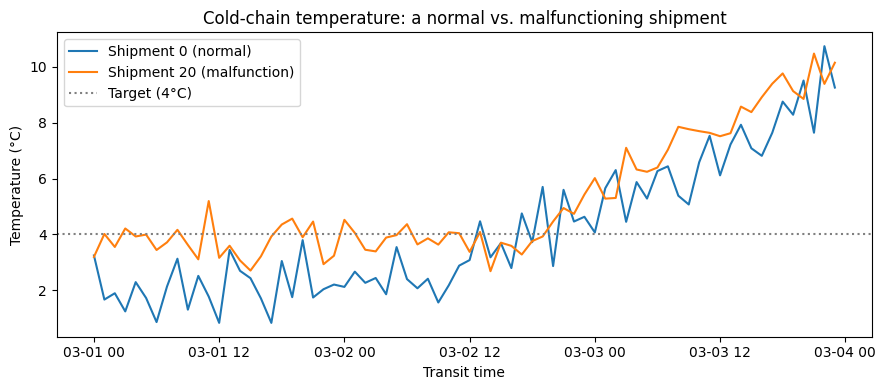

In [50]:
# The OO interface (fig, ax = plt.subplots()) instead of plt.plot() directly --
# this scales much better once we need multiple axes/subplots later on.
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(transit_time, cold_chain[0], label=f"Shipment 0 (normal)")
ax.plot(transit_time, cold_chain[malfunctioning[0]], label=f"Shipment {malfunctioning[0]} (malfunction)")
ax.axhline(target_temp_c, color="gray", linestyle=":", label="Target (4°C)")

ax.set_xlabel("Transit time")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Cold-chain temperature: a normal vs. malfunctioning shipment")
ax.legend()
plt.tight_layout()
plt.show()


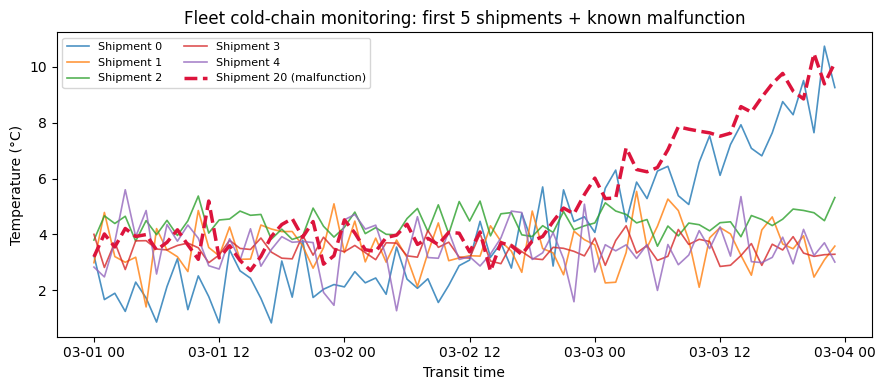

In [51]:
# Line style / color / marker customization, and plotting several shipments
# at once with a loop -- exactly how you'd build a fleet-monitoring chart
fig, ax = plt.subplots(figsize=(9, 4))
for s in range(5):
    ax.plot(transit_time, cold_chain[s], lw=1.2, alpha=0.8, label=f"Shipment {s}")

ax.plot(transit_time, cold_chain[malfunctioning[0]], color="crimson", lw=2.5,
        linestyle="--", label=f"Shipment {malfunctioning[0]} (malfunction)")

ax.set(xlabel="Transit time", ylabel="Temperature (°C)",
       title="Fleet cold-chain monitoring: first 5 shipments + known malfunction")
ax.legend(ncols=2, fontsize=8)
plt.tight_layout()
plt.show()


## 11. Simple Scatter Plots  *(ref: 04.02)*

Scatter plots reveal relationships between two continuous variables — here,
price vs. calories — and, with `s=`/`c=`, can encode two *more* variables
(rating and category) in a single figure.


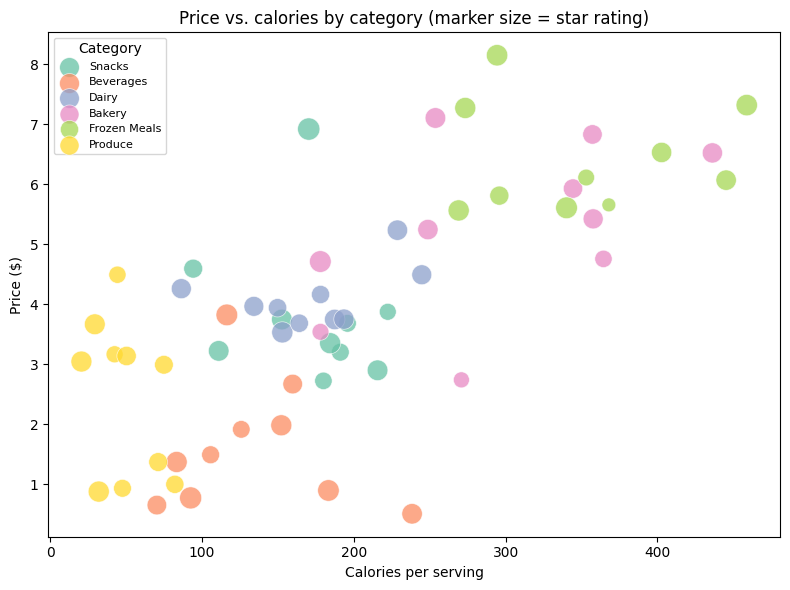

In [52]:
# ax.scatter() lets EVERY point vary independently in size and color --
# encoding rating (size) and category (color) on top of price vs calories
fig, ax = plt.subplots(figsize=(8, 6))
sizes = (ratings - 1) * 60 + 20   # map 1-5 star ratings to a reasonable marker-size range

for cat in categories:
    mask = product_category == cat
    ax.scatter(nutrients[mask, 0], prices[mask], s=sizes[mask],
               color=category_colors[cat], alpha=0.75, edgecolor="white", linewidth=0.5,
               label=cat)

ax.set_xlabel("Calories per serving")
ax.set_ylabel("Price ($)")
ax.set_title("Price vs. calories by category (marker size = star rating)")
ax.legend(title="Category", loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 12. Visualizing Errors  *(ref: 04.03)*

A single mean number hides variability that matters — error bars make the
*spread* of a measurement visible, e.g. how consistent each category's price
actually is.


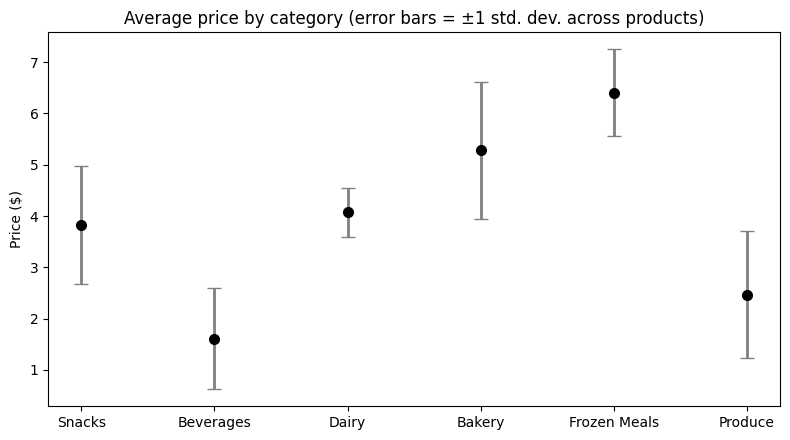

In [53]:
cat_price_mean = np.array([prices[product_category == c].mean() for c in categories])
cat_price_std  = np.array([prices[product_category == c].std()  for c in categories])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(categories, cat_price_mean, yerr=cat_price_std, fmt="o", color="black",
            ecolor="gray", elinewidth=2, capsize=5, markersize=7)

ax.set_ylabel("Price ($)")
ax.set_title("Average price by category (error bars = ±1 std. dev. across products)")
plt.tight_layout()
plt.show()


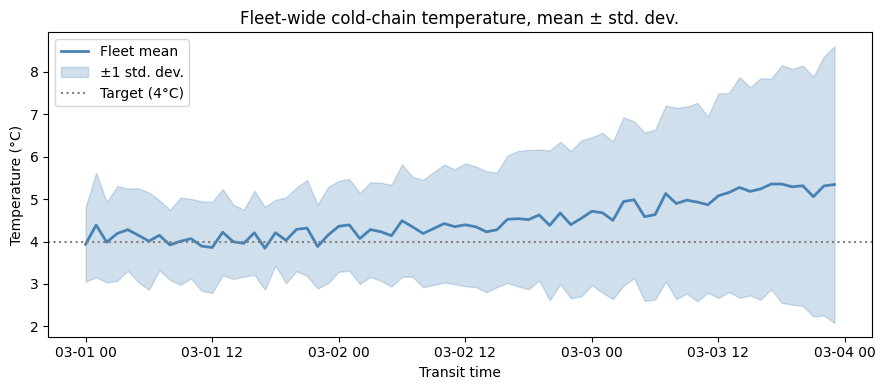

In [54]:
# Continuous error BANDS (fill_between) are often clearer than error bars
# for a time series -- here, the fleet's mean cold-chain temperature ± std
# across all 24 shipments, at every hour of transit
hourly_mean = cold_chain.mean(axis=0)
hourly_std = cold_chain.std(axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(transit_time, hourly_mean, color="steelblue", lw=2, label="Fleet mean")
ax.fill_between(transit_time, hourly_mean - hourly_std, hourly_mean + hourly_std,
                 color="steelblue", alpha=0.25, label="±1 std. dev.")
ax.axhline(target_temp_c, color="gray", linestyle=":", label="Target (4°C)")

ax.set(xlabel="Transit time", ylabel="Temperature (°C)",
       title="Fleet-wide cold-chain temperature, mean ± std. dev.")
ax.legend()
plt.tight_layout()
plt.show()


## 13. Density and Contour Plots  *(ref: 04.04)*

When two variables have LOTS of overlapping points, a scatter plot gets
muddy — density/contour plots show *where mass concentrates* instead.


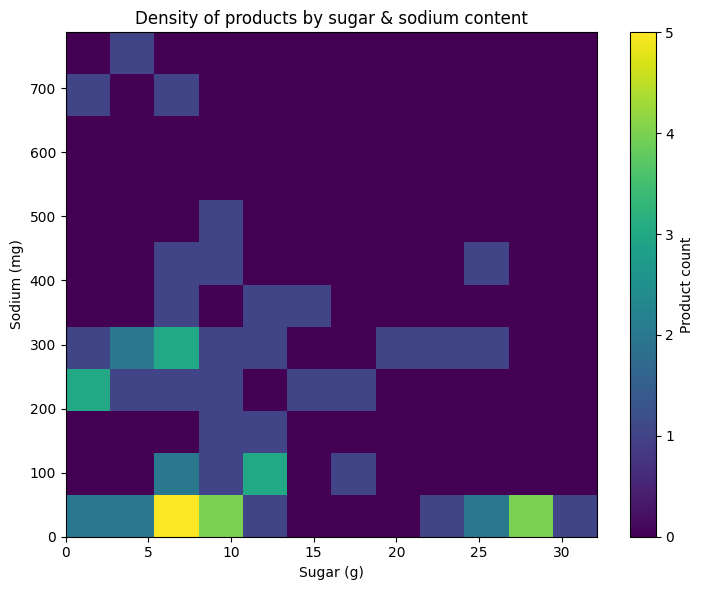

In [55]:
# A 2D histogram (np.histogram2d under the hood via plt.hist2d) of sugar vs
# sodium across the WHOLE catalog -- where do most products actually sit?
sugar_col = nutrient_names.tolist().index("sugar_g")

fig, ax = plt.subplots(figsize=(7.5, 6))
h = ax.hist2d(nutrients[:, sugar_col], nutrients[:, sodium_col], bins=12, cmap="viridis")
fig.colorbar(h[3], ax=ax, label="Product count")
ax.set_xlabel("Sugar (g)"); ax.set_ylabel("Sodium (mg)")
ax.set_title("Density of products by sugar & sodium content")
plt.tight_layout()
plt.show()


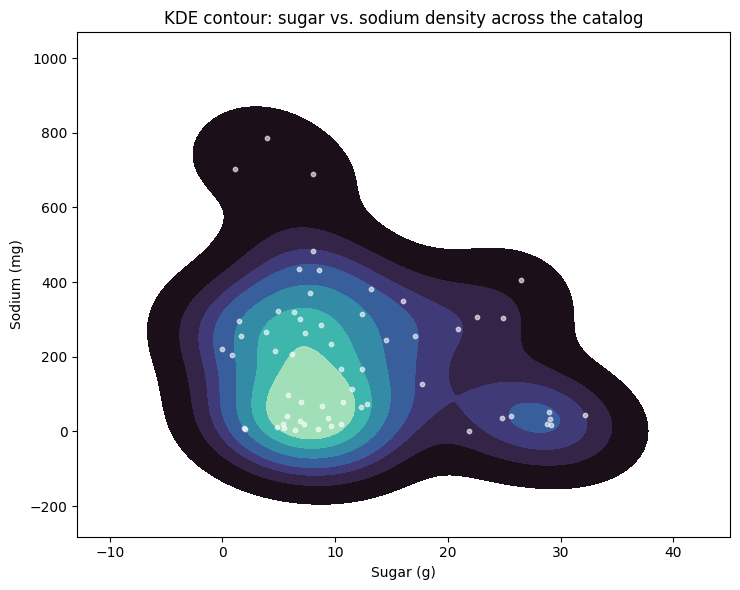

In [56]:
# A smooth KDE contour (via seaborn, which wraps scipy's gaussian_kde) tells
# the same story with a continuous density surface instead of discrete bins
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.kdeplot(x=nutrients[:, sugar_col], y=nutrients[:, sodium_col],
            fill=True, cmap="mako", thresh=0.05, levels=8, ax=ax)
ax.scatter(nutrients[:, sugar_col], nutrients[:, sodium_col], s=10, color="white", alpha=0.6)
ax.set_xlabel("Sugar (g)"); ax.set_ylabel("Sodium (mg)")
ax.set_title("KDE contour: sugar vs. sodium density across the catalog")
plt.tight_layout()
plt.show()


## 14. Histograms and Binning  *(ref: 04.05)*

The single most useful "first look" at any new numeric column — here,
the calorie distribution across the whole product catalog.


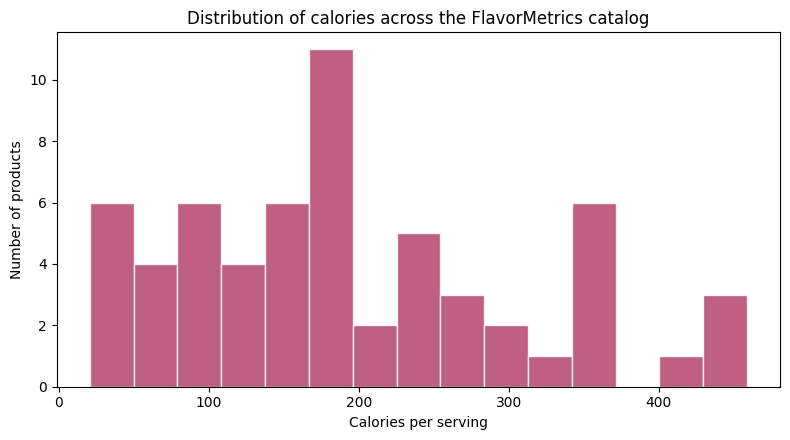

In [57]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(nutrients[:, 0], bins=15, color="#B4436C", edgecolor="white", alpha=0.85)
ax.set_xlabel("Calories per serving"); ax.set_ylabel("Number of products")
ax.set_title("Distribution of calories across the FlavorMetrics catalog")
plt.tight_layout()
plt.show()


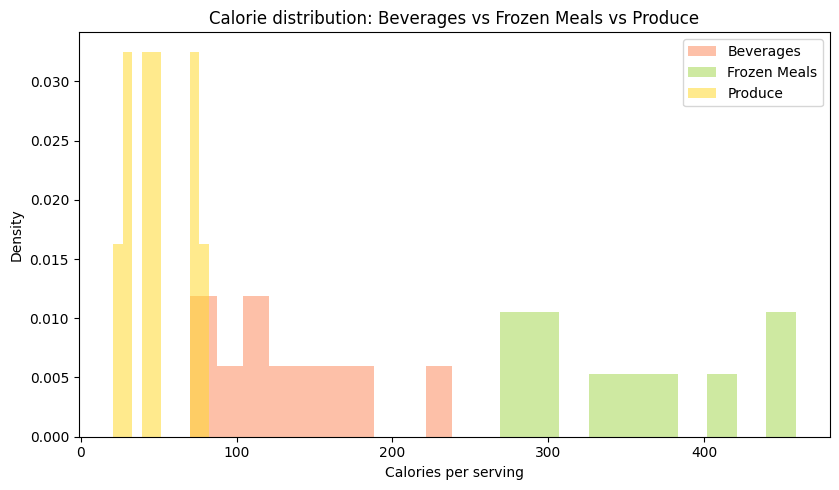

In [58]:
# Overlaid, semi-transparent histograms let us compare MULTIPLE categories'
# calorie distributions on one axis -- density=True normalizes for the fact
# that categories don't have equal product counts
fig, ax = plt.subplots(figsize=(8.5, 5))
for cat in ["Beverages", "Frozen Meals", "Produce"]:
    ax.hist(nutrients[product_category == cat, 0], bins=10, alpha=0.55,
            density=True, label=cat, color=category_colors[cat])

ax.set_xlabel("Calories per serving"); ax.set_ylabel("Density")
ax.set_title("Calorie distribution: Beverages vs Frozen Meals vs Produce")
ax.legend()
plt.tight_layout()
plt.show()


In [59]:
# np.histogram2d directly (rather than plt.hist2d) gives us the raw COUNT
# matrix, useful when we want the numbers as well as the picture -- e.g.
# a price-vs-rating 2D binning for a merchandising report
counts, price_edges, rating_edges = np.histogram2d(prices, ratings, bins=[6, 5])
print("2D histogram count matrix (rows=price bin, cols=rating bin):")
counts.astype(int)


2D histogram count matrix (rows=price bin, cols=rating bin):


array([[0, 0, 4, 2, 4],
       [0, 3, 1, 2, 2],
       [0, 4, 4, 8, 3],
       [0, 2, 1, 4, 2],
       [1, 1, 1, 5, 1],
       [0, 0, 0, 1, 4]])

## 15. Customizing Legends  *(ref: 04.06)*

Legends need real customization once a figure gets busy: placement, columns,
frame styling, and combining/reordering entries from multiple plot calls.


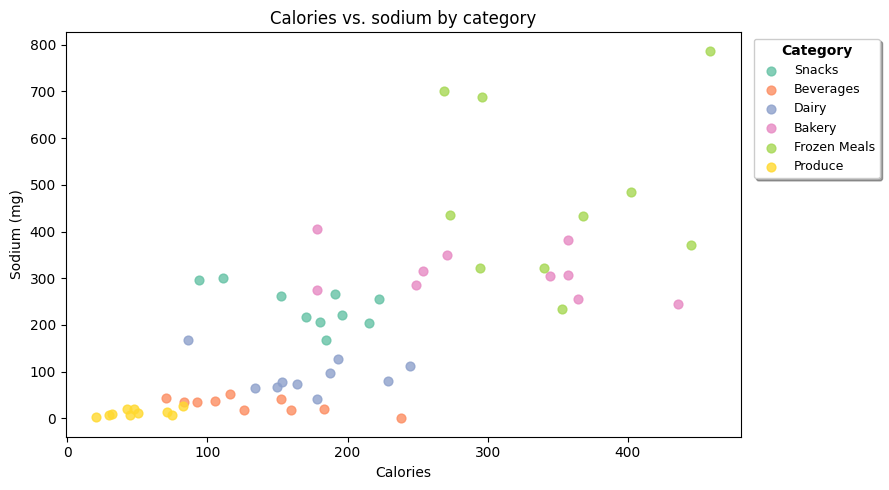

In [60]:
fig, ax = plt.subplots(figsize=(9, 5))
for cat in categories:
    mask = product_category == cat
    ax.scatter(nutrients[mask, 0], nutrients[mask, sodium_col],
               color=category_colors[cat], label=cat, s=40, alpha=0.8)

# fancybox + shadow + custom ncol + a title -- a fully styled legend, placed
# OUTSIDE the axes so it never overlaps data points
legend = ax.legend(title="Category", loc="upper left", bbox_to_anchor=(1.01, 1.0),
                    frameon=True, fancybox=True, shadow=True, ncols=1, fontsize=9)
legend.get_title().set_fontweight("bold")

ax.set_xlabel("Calories"); ax.set_ylabel("Sodium (mg)")
ax.set_title("Calories vs. sodium by category")
plt.tight_layout()
plt.show()


## 16. Customizing Colorbars  *(ref: 04.07)*

A colorbar is a legend for continuous data. We build a category-by-nutrient
heatmap and customize the colorbar's ticks, label, and extent explicitly.


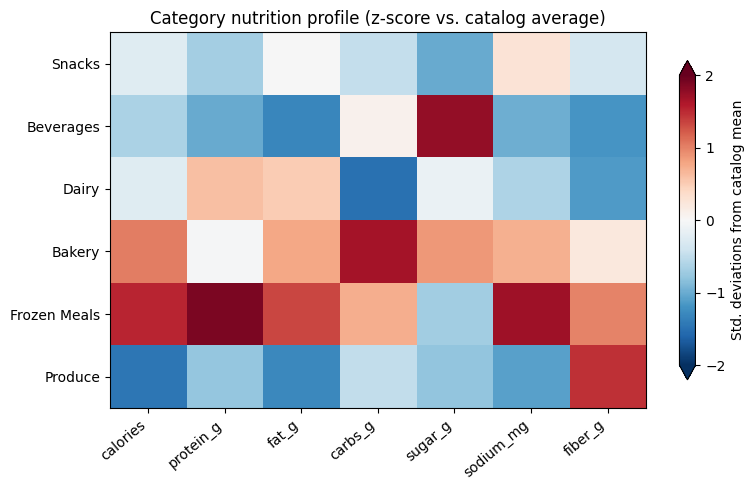

In [61]:
# Category-average nutrition profile: a (categories x nutrients) matrix,
# z-scored per nutrient so very different scales (calories vs sodium) are
# visually comparable on one shared colorbar
cat_avg = np.array([nutrients[product_category == c].mean(axis=0) for c in categories])
cat_avg_z = (cat_avg - cat_avg.mean(axis=0)) / cat_avg.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(cat_avg_z, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")

ax.set_xticks(range(len(nutrient_names))); ax.set_xticklabels(nutrient_names, rotation=40, ha="right")
ax.set_yticks(range(len(categories))); ax.set_yticklabels(categories)
ax.set_title("Category nutrition profile (z-score vs. catalog average)")

cbar = fig.colorbar(im, ax=ax, extend="both", shrink=0.85)
cbar.set_label("Std. deviations from catalog mean")
cbar.set_ticks([-2, -1, 0, 1, 2])
plt.tight_layout()
plt.show()


## 17. Multiple Subplots  *(ref: 04.08)*

A real report is rarely one chart — `plt.subplots()` (and `GridSpec` for
uneven layouts) let us build a small operations **dashboard** in one figure.


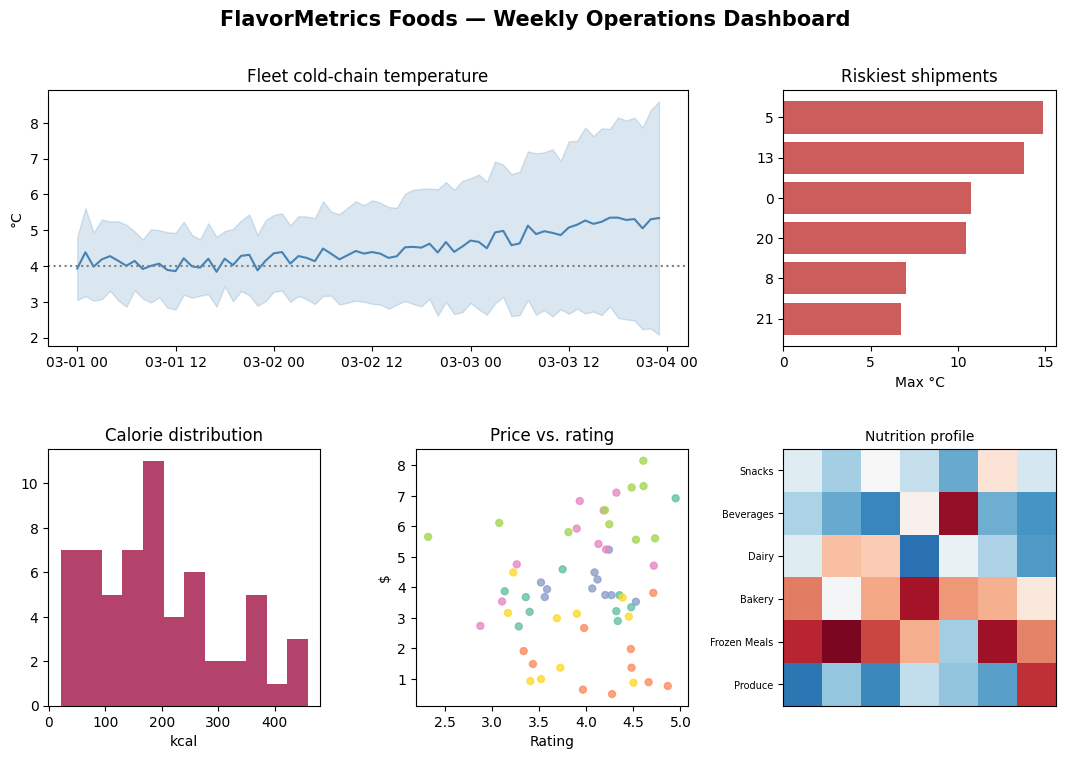

In [62]:
fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# Panel 1 (spans 2 columns): fleet temperature trend
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(transit_time, hourly_mean, color="steelblue")
ax1.fill_between(transit_time, hourly_mean - hourly_std, hourly_mean + hourly_std, alpha=0.2, color="steelblue")
ax1.axhline(target_temp_c, color="gray", ls=":")
ax1.set_title("Fleet cold-chain temperature"); ax1.set_ylabel("°C")

# Panel 2: worst-shipment ranking (horizontal bar)
ax2 = fig.add_subplot(gs[0, 2])
top6 = risk_order[:6]
ax2.barh([str(s) for s in top6][::-1], shipment_max[top6][::-1], color="indianred")
ax2.set_title("Riskiest shipments"); ax2.set_xlabel("Max °C")

# Panel 3: calorie histogram
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(nutrients[:, 0], bins=12, color="#B4436C")
ax3.set_title("Calorie distribution"); ax3.set_xlabel("kcal")

# Panel 4: price vs rating scatter
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(ratings, prices, c=category_color_array, s=25, alpha=0.8)
ax4.set_title("Price vs. rating"); ax4.set_xlabel("Rating"); ax4.set_ylabel("$")

# Panel 5: category nutrition heatmap (compact)
ax5 = fig.add_subplot(gs[1, 2])
im = ax5.imshow(cat_avg_z, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax5.set_yticks(range(len(categories))); ax5.set_yticklabels(categories, fontsize=7)
ax5.set_xticks([]); ax5.set_title("Nutrition profile", fontsize=10)

fig.suptitle("FlavorMetrics Foods — Weekly Operations Dashboard", fontsize=15, fontweight="bold")
plt.show()


## 18. Text and Annotation  *(ref: 04.09)*

Raw data rarely explains itself — `ax.annotate()`/`ax.text()` let us point
directly at the outliers and events that matter.


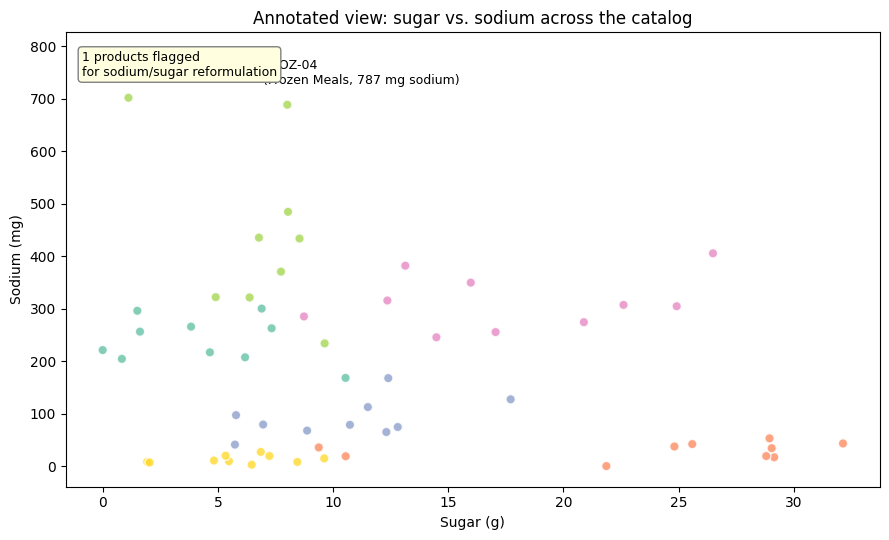

In [63]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(nutrients[:, sugar_col], nutrients[:, sodium_col],
           c=category_color_array, s=45, alpha=0.8, edgecolor="white")

# Annotate the single highest-sodium product with an arrow, pulling its name
# and category directly from the arrays -- not hardcoded
idx = top_sodium_idx
ax.annotate(
    f"{product_names[idx]}\n({product_category[idx]}, {nutrients[idx, sodium_col]:.0f} mg sodium)",
    xy=(nutrients[idx, sugar_col], nutrients[idx, sodium_col]),
    xytext=(nutrients[idx, sugar_col] + 3, nutrients[idx, sodium_col] - 60),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9, ha="left",
)

# A plain text box (no arrow) calling out a general finding
ax.text(0.02, 0.96, f"{reformulation_candidates.sum()} products flagged\nfor sodium/sugar reformulation",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

ax.set_xlabel("Sugar (g)"); ax.set_ylabel("Sodium (mg)")
ax.set_title("Annotated view: sugar vs. sodium across the catalog")
plt.tight_layout()
plt.show()


## 19. Customizing Ticks  *(ref: 04.10)*

Default tick placement/formatting is rarely exactly right for a business
audience — we control locators, formatters, and rotation explicitly.


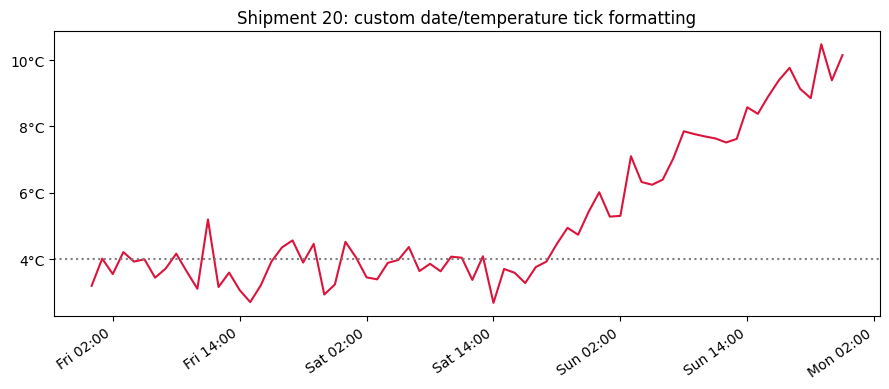

In [64]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(transit_time, cold_chain[malfunctioning[0]], color="crimson")
ax.axhline(target_temp_c, color="gray", ls=":")

# Date axis: a tick every 12 hours, formatted as "Mon 06:00", rotated for readability
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M"))
fig.autofmt_xdate(rotation=35)

# Y-axis: force a tick exactly every 2 degrees, formatted with a ° suffix
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f°C"))

ax.set_title(f"Shipment {malfunctioning[0]}: custom date/temperature tick formatting")
plt.tight_layout()
plt.show()


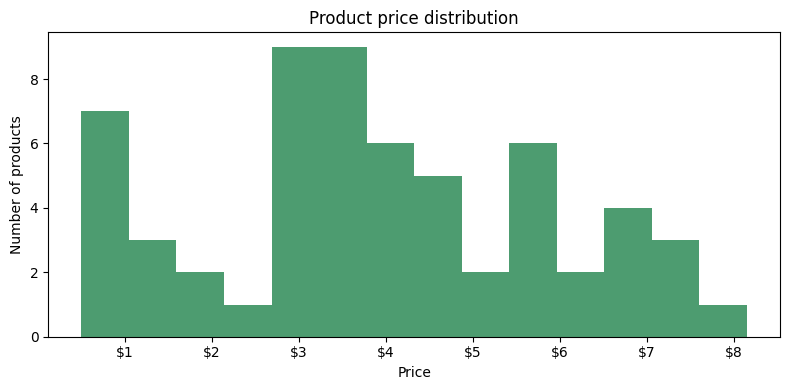

In [65]:
# Currency-formatted axis for the price distribution -- a small but very
# real polish businesses actually ask for
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prices, bins=14, color="seagreen", alpha=0.85)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
ax.set_xlabel("Price"); ax.set_ylabel("Number of products")
ax.set_title("Product price distribution")
plt.tight_layout()
plt.show()


## 20. Settings and Stylesheets  *(ref: 04.11)*

Style sheets apply a consistent, professional look across an entire report
without manually restyling every figure — useful for a shared team dashboard.


In [66]:
print("A sample of available styles:", plt.style.available[:8], "...")


A sample of available styles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast'] ...


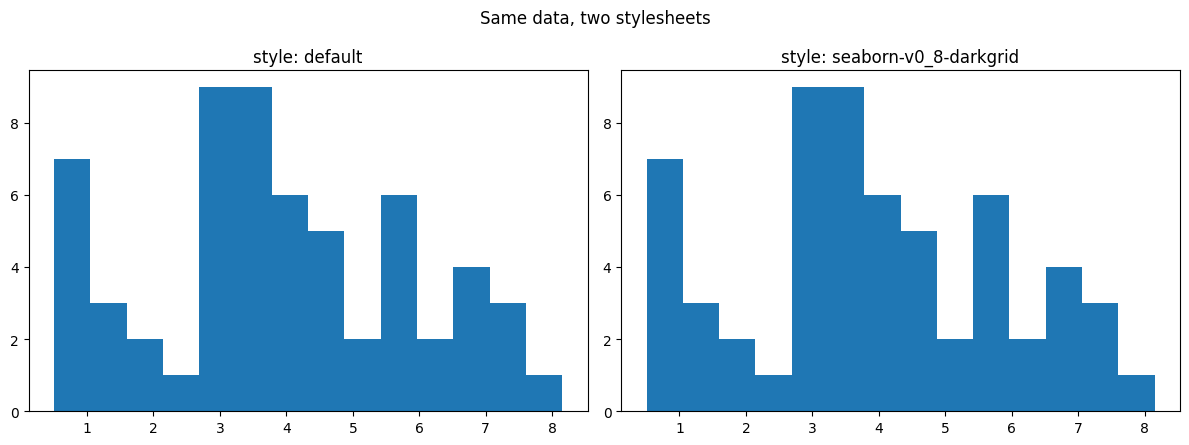

In [67]:
# Compare the SAME chart under two different global style contexts, using
# `with plt.style.context(...)` so the style doesn't leak into later cells
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

with plt.style.context("default"):
    axes[0].hist(prices, bins=14, color="C0")
    axes[0].set_title("style: default")

with plt.style.context("seaborn-v0_8-darkgrid"):
    axes[1].hist(prices, bins=14, color="C0")
    axes[1].set_title("style: seaborn-v0_8-darkgrid")

fig.suptitle("Same data, two stylesheets")
plt.tight_layout()
plt.show()


In [68]:
# For the REST of this notebook's remaining figures, apply one consistent
# FlavorMetrics house style globally via rcParams -- this is how a team
# would standardize every chart in a shared reporting notebook
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
print("House style applied for the remaining figures.")


House style applied for the remaining figures.


## 21. Three-Dimensional Plotting  *(ref: 04.12)*

Most business charts should stay 2D — but a genuinely 3-variable relationship
(here, the protein/fat/carb "macro space" of every product) is one of the
few honest uses of `mplot3d`.


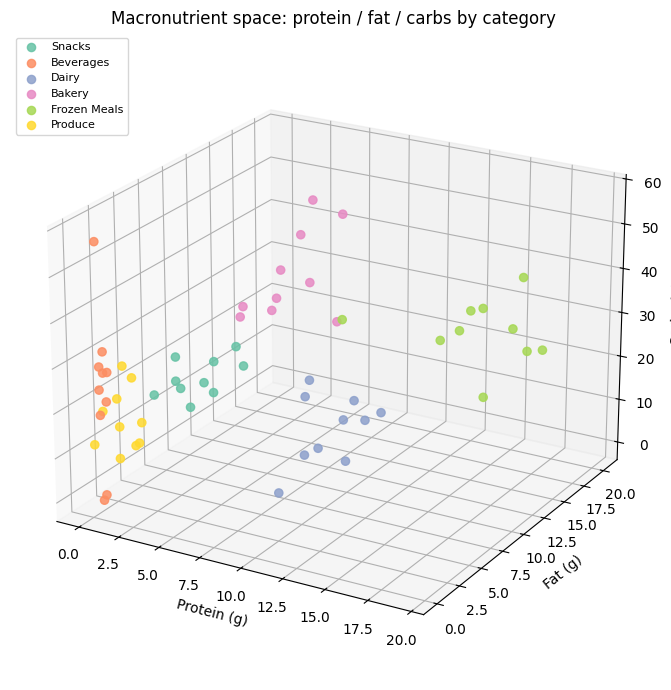

In [69]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 -- registers the '3d' projection

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for cat in categories:
    mask = product_category == cat
    ax.scatter(nutrients[mask, 1], nutrients[mask, 2], nutrients[mask, 3],
               color=category_colors[cat], label=cat, s=35, alpha=0.85)

ax.set_xlabel("Protein (g)"); ax.set_ylabel("Fat (g)"); ax.set_zlabel("Carbs (g)")
ax.set_title("Macronutrient space: protein / fat / carbs by category")
ax.legend(loc="upper left", fontsize=8, bbox_to_anchor=(0, 1))
ax.view_init(elev=22, azim=-60)
plt.tight_layout()
plt.show()


## 22. Geographic Data  *(ref: 04.13)*

> **A note on Basemap:** the handbook's original chapter used the
> `mpl_toolkits.basemap` package, which has since been **deprecated** in
> favor of `cartopy` and `geopandas`. Those modern libraries typically need
> to download Natural Earth shapefiles at runtime, which isn't possible in
> this offline notebook environment. Instead, we demonstrate the same
> underlying idea — a longitude/latitude **bubble map** with a value encoded
> in color and size — using plain Matplotlib. In a production environment
> with internet access, you'd swap the code below almost directly for
> `cartopy.crs`/`ax.coastlines()` to get real coastlines and borders under
> the same points.


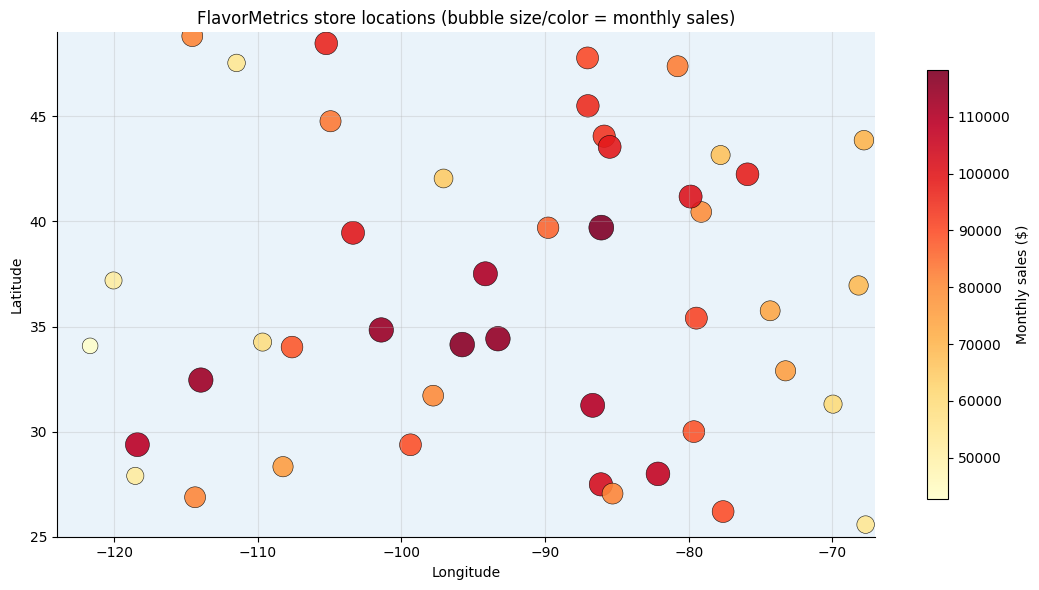

In [70]:
fig, ax = plt.subplots(figsize=(11, 6))

# A simple lon/lat bounding-box "canvas" standing in for a real basemap
ax.set_xlim(lon_range); ax.set_ylim(lat_range)
ax.set_facecolor("#eaf3fa")   # a light "ocean" background tint
ax.grid(True, alpha=0.3)

sizes = store_sales / store_sales.max() * 300 + 20
sc = ax.scatter(store_lon, store_lat, s=sizes, c=store_sales, cmap="YlOrRd",
                 edgecolor="black", linewidth=0.4, alpha=0.9)

cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Monthly sales ($)")

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("FlavorMetrics store locations (bubble size/color = monthly sales)")
plt.tight_layout()
plt.show()


In [71]:
# The same geographic data, aggregated by region (East/West) -- a groupby-
# style summary that pairs naturally with the map above
for region in ["West", "East"]:
    mask = store_region == region
    print(f"{region:5s}: {mask.sum():2d} stores, avg monthly sales "
          f"${store_sales[mask].mean():,.0f}")


West : 15 stores, avg monthly sales $80,356
East : 30 stores, avg monthly sales $88,754


## 23. Visualization with Seaborn  *(ref: 04.14)*

Seaborn builds on Matplotlib with statistically-aware defaults — easier
multi-variable comparisons, distributions, and correlation views with far
less boilerplate for these particular chart types.


In [72]:
# Bring the arrays together into ONE pandas DataFrame just for Seaborn's API,
# which expects a "tidy" table -- everything IN the table still ultimately
# came from the NumPy computations in Part A.
food_df = pd.DataFrame({
    "product": product_names, "category": product_category, "price": prices, "rating": ratings,
    **{n: nutrients[:, i] for i, n in enumerate(nutrient_names)},
})
food_df.head()


,product,category,price,rating,calories,protein_g,fat_g,carbs_g,sugar_g,sodium_mg,fiber_g
0,SNAC-01,Snacks,3.198224,3.401281,191.154275,3.139760,10.709189,18.284096,3.837092,265.703708,1.011986
1,SNAC-02,Snacks,2.896781,4.335651,215.676802,1.768677,3.558256,20.122846,0.833949,204.292577,0.887689
2,SNAC-03,Snacks,3.679510,3.360950,195.868781,1.392283,6.397722,19.124717,0.000000,221.047869,0.994393
3,SNAC-04,Snacks,3.219962,4.320097,111.072819,3.984406,8.491366,26.288420,6.902903,300.116244,0.962716
4,SNAC-05,Snacks,4.591285,3.751125,94.287996,2.548912,5.994589,14.681620,1.504201,295.927119,1.139111


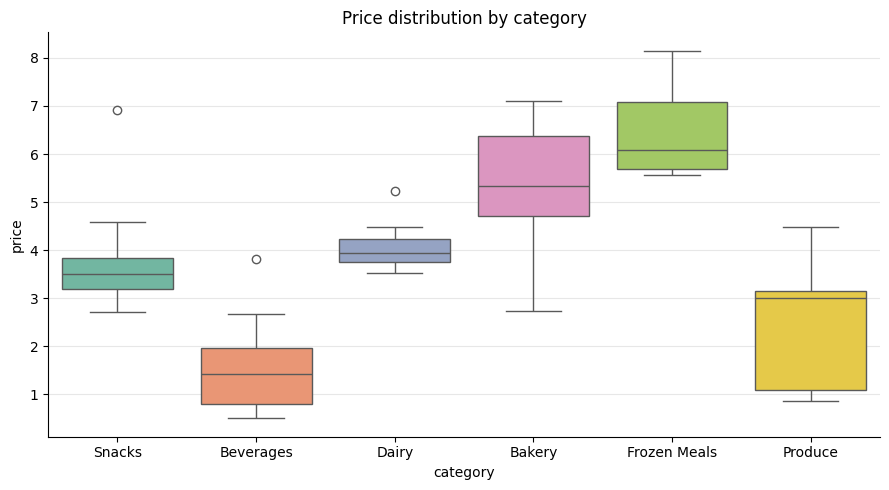

In [73]:
# sns.boxplot: price distribution BY category, with quartiles/outliers shown
# automatically -- much more informative than a single mean bar
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=food_df, x="category", y="price", hue="category",
            palette=category_colors, legend=False, ax=ax)
ax.set_title("Price distribution by category")
plt.tight_layout()
plt.show()


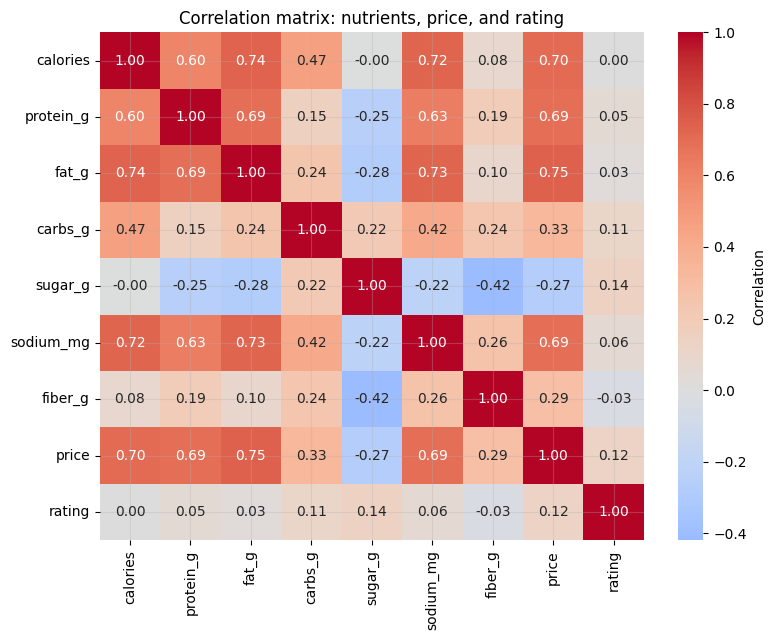

In [74]:
# sns.heatmap: full nutrient CORRELATION matrix -- which nutrients tend to
# move together across the catalog (e.g. does higher fat track with higher calories?)
corr = food_df[nutrient_names.tolist() + ["price", "rating"]].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("Correlation matrix: nutrients, price, and rating")
plt.tight_layout()
plt.show()


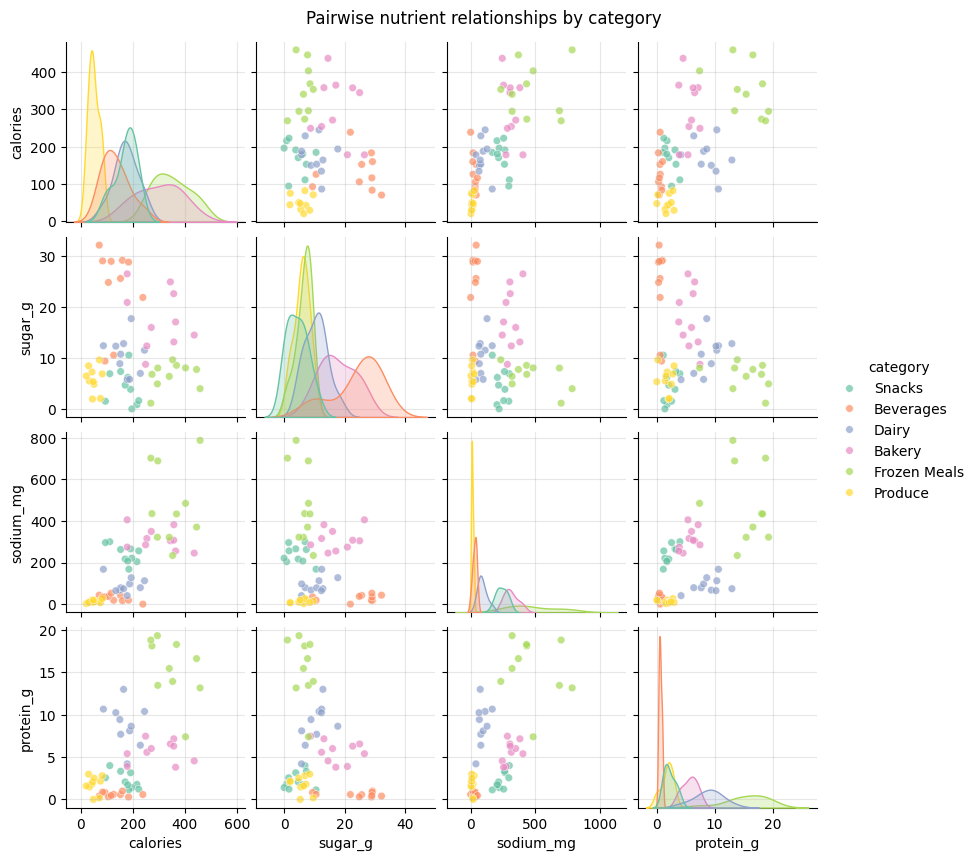

In [75]:
# sns.pairplot: every pairwise nutrient relationship AND each nutrient's own
# distribution, colored by category, all generated in one call
g = sns.pairplot(food_df, vars=["calories", "sugar_g", "sodium_mg", "protein_g"],
                  hue="category", palette=category_colors, plot_kws=dict(alpha=0.7, s=30),
                  diag_kind="kde", height=2.1)
g.fig.suptitle("Pairwise nutrient relationships by category", y=1.02)
plt.show()


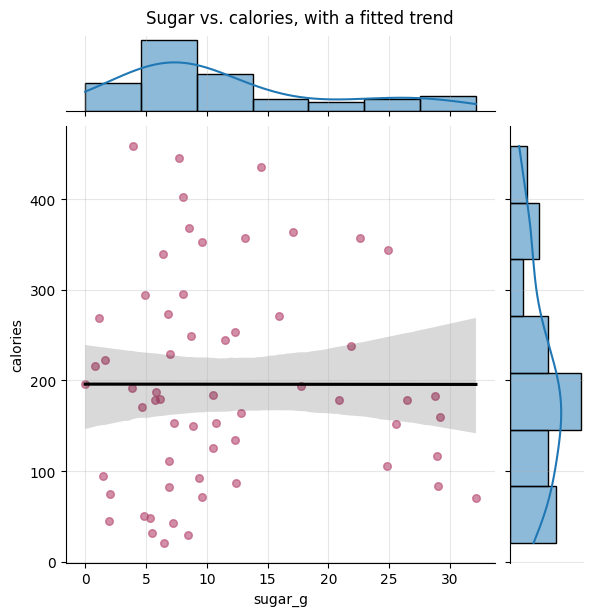

In [76]:
# sns.jointplot: a scatter + marginal histograms for ONE specific pair,
# with a regression line -- a common "is there a relationship here?" chart
g = sns.jointplot(data=food_df, x="sugar_g", y="calories", kind="reg",
                   height=6, scatter_kws=dict(alpha=0.6, s=30, color="#B4436C"),
                   line_kws=dict(color="black"))
g.fig.suptitle("Sugar vs. calories, with a fitted trend", y=1.02)
plt.show()


## 24. Wrap-up & Further Resources  *(ref: 04.15)*

### What we built
Two linked skill sets, both grounded entirely in real FlavorMetrics
food-industry data:

**NumPy (Part A)** — dtype-aware storage decisions, array attributes and
slicing/reshaping, vectorized ufunc computation (unit conversions, calorie
verification), axis-aware aggregation, broadcasting for recipe-scaling and
normalization, boolean masking for food-safety excursions and reformulation
targeting, fancy indexing for sampling/audits, sorting/partitioning for
risk-ranking, and structured arrays for a mixed-type QC log.

**Visualization (Part B)** — line/scatter/error-bar/density/histogram
fundamentals, then legend/colorbar/tick/style customization, a full
multi-panel operations dashboard, text annotation, 3D macronutrient space,
a geographic bubble map, and Seaborn's statistically-aware chart types.

### Techniques applied, chapter by chapter
| Chapter | Technique | Where we used it |
|---|---|---|
| 02.01 | Data types | Choosing int8/float32/bool for category codes, nutrients, allergens |
| 02.02 | Array basics | Attributes, slicing/views, reshape, concatenate on the nutrition matrix |
| 02.03 | Ufuncs | Unit conversion, Atwater calorie check, sweetness index |
| 02.04 | Aggregations | Catalog-wide stats, per-shipment min/mean/max/percentile |
| 02.05 | Broadcasting | Recipe batch scaling, waste-factor adjustment, min-max normalization |
| 02.06 | Boolean masks | Cold-chain excursion detection, reformulation-candidate targeting |
| 02.07 | Fancy indexing | Spotlight selection, random QA sampling, targeted reformulation edit |
| 02.08 | Sorting | Sodium leaderboard, shipment risk ranking, top-k partitioning |
| 02.09 | Structured arrays | Mixed-type QC inspection log |
| 04.01–04.03 | Line/scatter/error plots | Temperature trends, price-vs-calories, category price variability |
| 04.04–04.05 | Density/contour, histograms | Sugar-vs-sodium density, calorie distributions |
| 04.06–04.07 | Legends, colorbars | Styled category legend, z-scored nutrition heatmap |
| 04.08–04.10 | Subplots, annotation, ticks | Ops dashboard, outlier callouts, date/currency tick formatting |
| 04.11 | Stylesheets | House style applied via `rcParams` |
| 04.12–04.13 | 3D & geographic | Macronutrient 3D scatter, store-location bubble map |
| 04.14 | Seaborn | Boxplot, correlation heatmap, pairplot, jointplot |

### Where to go next
- Swap in a real point-of-sale / nutrition-database extract (e.g. USDA
  FoodData Central or a retailer's own POS system) and rerun this pipeline
  unchanged.
- For real geographic mapping, replace Part B §22 with `cartopy` (coastlines,
  state borders) or `geopandas` (choropleth by state/region) once shapefile
  access is available.
- Push the cold-chain excursion detection into a real-time alerting rule
  (e.g. using `numpy`'s vectorized comparisons inside a streaming pipeline).
- The original handbook chapter closes by pointing to the Matplotlib gallery
  (https://matplotlib.org/stable/gallery/) and the Seaborn example gallery
  (https://seaborn.pydata.org/examples/) as the best next stops for more
  chart types and customization patterns.
